In [ ]:
import pandas as pd
import re
from unidecode import unidecode
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC 
from nltk.corpus import stopwords
import nltk
from nltk.tokenize.toktok import ToktokTokenizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.decomposition import LatentDirichletAllocation
from scipy.sparse import hstack


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /home/user/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/user/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/user/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [88]:
data = pd.read_csv("IMDB Dataset.csv")

In [89]:
def preprocess_text(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    
    text = re.sub(r"<.*?>", "", text)  
    text = re.sub(r"http\S+|www\S+|https\S+", "", text) 
    text = re.sub(r"[^a-zA-Z\s]", "", text)  
    text = text.lower()  
    

    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    
    return " ".join(tokens)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    data['review'], data['sentiment'], test_size=0.2, random_state=42
)

In [127]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    max_df=0.1,
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)



In [ ]:
lda = LatentDirichletAllocation(n_components=10, random_state=42)
X_train_lda = lda.fit_transform(X_train_tfidf)
X_test_lda = lda.transform(X_test_tfidf)

X_train_combined = hstack([X_train_tfidf, X_train_lda])
X_test_combined = hstack([X_test_tfidf, X_test_lda])

In [ ]:
param_grid = {'C': [0.1, 1, 10, 100]}
grid_search = GridSearchCV(LinearSVC(random_state=42), param_grid, cv=3, n_jobs=1)  

X_train_subsample, _, y_train_subsample, _ = train_test_split(X_train_combined, y_train, train_size=0.1, random_state=42)
grid_search.fit(X_train_subsample, y_train_subsample)


/home/user/Desktop/summer2/filoger/nlp/HW3/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1243: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/user/Desktop/summer2/filoger/nlp/HW3/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1243: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/user/Desktop/summer2/filoger/nlp/HW3/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1243: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


GridSearchCV(cv=3, estimator=LinearSVC(random_state=42), n_jobs=1,
             param_grid={'C': [0.1, 1, 10, 100]})

In [122]:

model = LinearSVC(C=100,random_state=42)
model.fit(X_train_combined, y_train)


y_pred = model.predict(X_test_combined)

/home/user/Desktop/summer2/filoger/nlp/HW3/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1243: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [123]:
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred, pos_label='positive'))


Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.91      0.92      4961
    positive       0.91      0.94      0.92      5039

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

F1-Score: 0.923468887800098


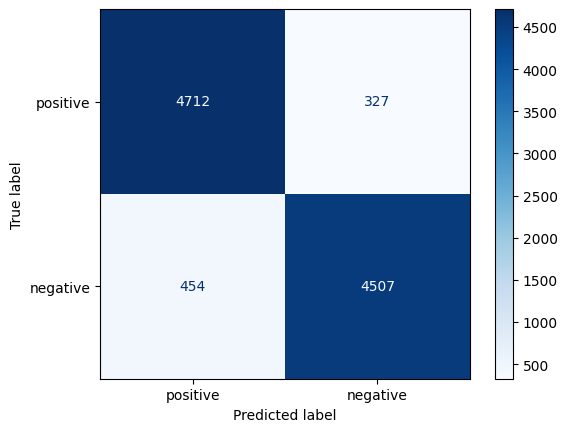

In [124]:
cm = confusion_matrix(y_test, y_pred, labels=['positive', 'negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative'])
disp.plot(cmap='Blues')
plt.show()

<div dir="rtl">

## گزارش طبقه‌بندی و تحلیل ماتریس درهم‌ریختگی

### معیارهای طبقه‌بندی

#### دقت (Precision):
- **کلاس منفی:** 0.93
- **کلاس مثبت:** 0.91
- **میانگین وزنی:** 0.92
دقت نشان می‌دهد چه درصدی از پیش‌بینی‌های انجام شده برای هر کلاس درسته.

#### بازخوانی (Recall):
- **کلاس منفی:** 0.91
- **کلاس مثبت:** 0.94
- **میانگین وزنی:** 0.92

بازخوانی درصد نمونه‌های پیش‌بینی شده درست از کل نمونه‌های واقعی هر کلاس را نشان می‌ده.
#### امتیاز F1 (F1-Score):
- **کلاس منفی:** 0.92
- **کلاس مثبت:** 0.92
- **میانگین وزنی:** 0.92

امتیاز F1 میانگین هارمونیک دقت و بازخوانیه و تعادل بین این دو را نشان می‌دهد.

#### دقت کلی (Accuracy):
- دقت کلی: **0.92**
  
این مقدار نسبت پیش‌بینی‌های درست به تعداد کل نمونه‌ها را نشان می‌دهد.

---

### ماتریس درهم‌ریختگی

|                | پیش‌بینی مثبت | پیش‌بینی منفی |
|----------------|--------------------|--------------------|
| **مثبت درست (True Positive):** | 4712               | 327                |
| **منفی درست (True Negative):** | 4507               | 454                |

#### مشاهدات کلیدی:
1. **مثبت‌های درست (TP):** 4712
2. **منفی‌های درست (TN):** 4507
3. **مثبت‌های کاذب (FP):** 327
4. **منفی‌های کاذب (FN):** 454

ماتریس درهم‌ریختگی توزیع پیش‌بینی‌های درست و نادرست را در هر دو کلاس نشان می‌دهد.

---

### تحلیل کلی
1. مدل برای هر دو کلاس مثبت و منفی عملکرد خوبی دارد و دقت، بازخوانی و امتیاز F1 متوازن هستند.
2. بازخوانی برای کلاس مثبت کمی بالاتر است که نشان می‌دهد مدل در شناسایی مثبت‌های درست بهتر عمل می‌کند.

---

